In [1]:
import pandas as pd
import matplotlib.pyplot as mpl
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import torch
import re
# tangermeme packages
from tangermeme.seqlet import recursive_seqlets
from tangermeme.plot import plot_logo
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme

In [3]:
# call seqlets and save bed files for ALL promoter predictions

In [4]:
# define function to convert predictions to final df
def vcf2df (pred_df):
    # make lists of preds for new column
    # k562
    k_ref = []
    k_alt = []
    k_skew = []
    # hepg2
    h_ref = []
    h_alt = []
    h_skew = []
    # sknsh
    s_ref = []
    s_alt = []
    s_skew = []
    gene_name = []
    # parse predictions in 'INFO' column
    for i in tqdm(pred_df['INFO']):
        all_preds = i.split(';')
        # k562
        k_ref.append(float(all_preds[0].split('=')[-1]))
        k_alt.append(float(all_preds[3].split('=')[-1]))
        k_skew.append(float(all_preds[6].split('=')[-1]))
        # hepg2
        h_ref.append(float(all_preds[1].split('=')[-1]))
        h_alt.append(float(all_preds[4].split('=')[-1]))
        h_skew.append(float(all_preds[7].split('=')[-1]))
        # sknsh
        s_ref.append(float(all_preds[2].split('=')[-1]))
        s_alt.append(float(all_preds[5].split('=')[-1]))
        s_skew.append(float(all_preds[8].split('=')[-1]))
        # add annotated gene name
        gene_name.append(all_preds[-1].split('=')[-1])
    
    df = pd.DataFrame({'chrom' : pred_df['#CHROM'],
                       'pos' : pred_df['POS'],
                       'id' : pred_df['ID'],
                       'ref' : pred_df['REF'],
                       'alt' : pred_df['ALT'],
                       'k562_ref_pred' : k_ref,
                       'k562_alt_pred' : k_alt,
                       'k562_skew_pred' : k_skew,
                       'hepg2_ref_pred' : h_ref,
                       'hepg2_alt_pred' : h_alt,
                       'hepg2_skew_pred' : h_skew,
                       'sknsh_ref_pred' : s_ref,
                       'sknsh_alt_pred' : s_alt,
                       'sknsh_skew_pred' : s_skew,
                       'gene_name' : gene_name})
    return df

In [2]:
def read_in_sat_mut (path2satmut, chunksize):
    chunks2cat = []
    for chunk in tqdm(pd.read_csv(path2satmut, sep = '\t', chunksize=chunksize)):
        chunks2cat.append(chunk)
    cat_df = pd.concat(chunks2cat)
    return cat_df

In [5]:
# open tabix filtered (tabix_filter_mpac_preds.sh) predictions and reformat for downstream analyses
mpac_preds = vcf2df(read_in_sat_mut('../mpac/processed_data/all.gencode.v44.canonical.protein.coding.1kb.promoters.sat.mut.updated.pos.vcf.gz', 1000000))

57it [03:28,  3.66s/it]
 49%|████▉     | 27556996/56281953 [01:26<01:30, 316779.68it/s]


KeyboardInterrupt: 

In [ ]:
mpac_preds.head()

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,hepg2_skew_pred,sknsh_ref_pred,sknsh_alt_pred,sknsh_skew_pred,gene_name
0,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,T,0.368796,0.355564,-0.013233,0.367238,0.344585,-0.022653,0.558187,0.530182,-0.028004,OR4F5
1,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,C,0.368796,0.382817,0.014021,0.367238,0.361899,-0.005339,0.558187,0.547707,-0.010479,OR4F5
2,chr1,65169,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,A,G,0.368796,0.373723,0.004927,0.367238,0.363106,-0.004132,0.558187,0.539187,-0.019000,OR4F5
3,chr1,65170,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,G,A,0.287499,0.341029,0.053531,0.352586,0.411632,0.059047,0.538484,0.640290,0.101806,OR4F5
4,chr1,65170,ENSG00000186092.7_ENST00000641515.2_OR4F5..chr...,G,T,0.287499,0.278900,-0.008599,0.352586,0.349975,-0.002611,0.538484,0.525039,-0.013445,OR4F5


There are 16285 unique gene IDs in the full predictions
There are 13003 non-overlapping promoters with complete sat mut predictions
There are 3282 genes that are not passing filtering
True
True


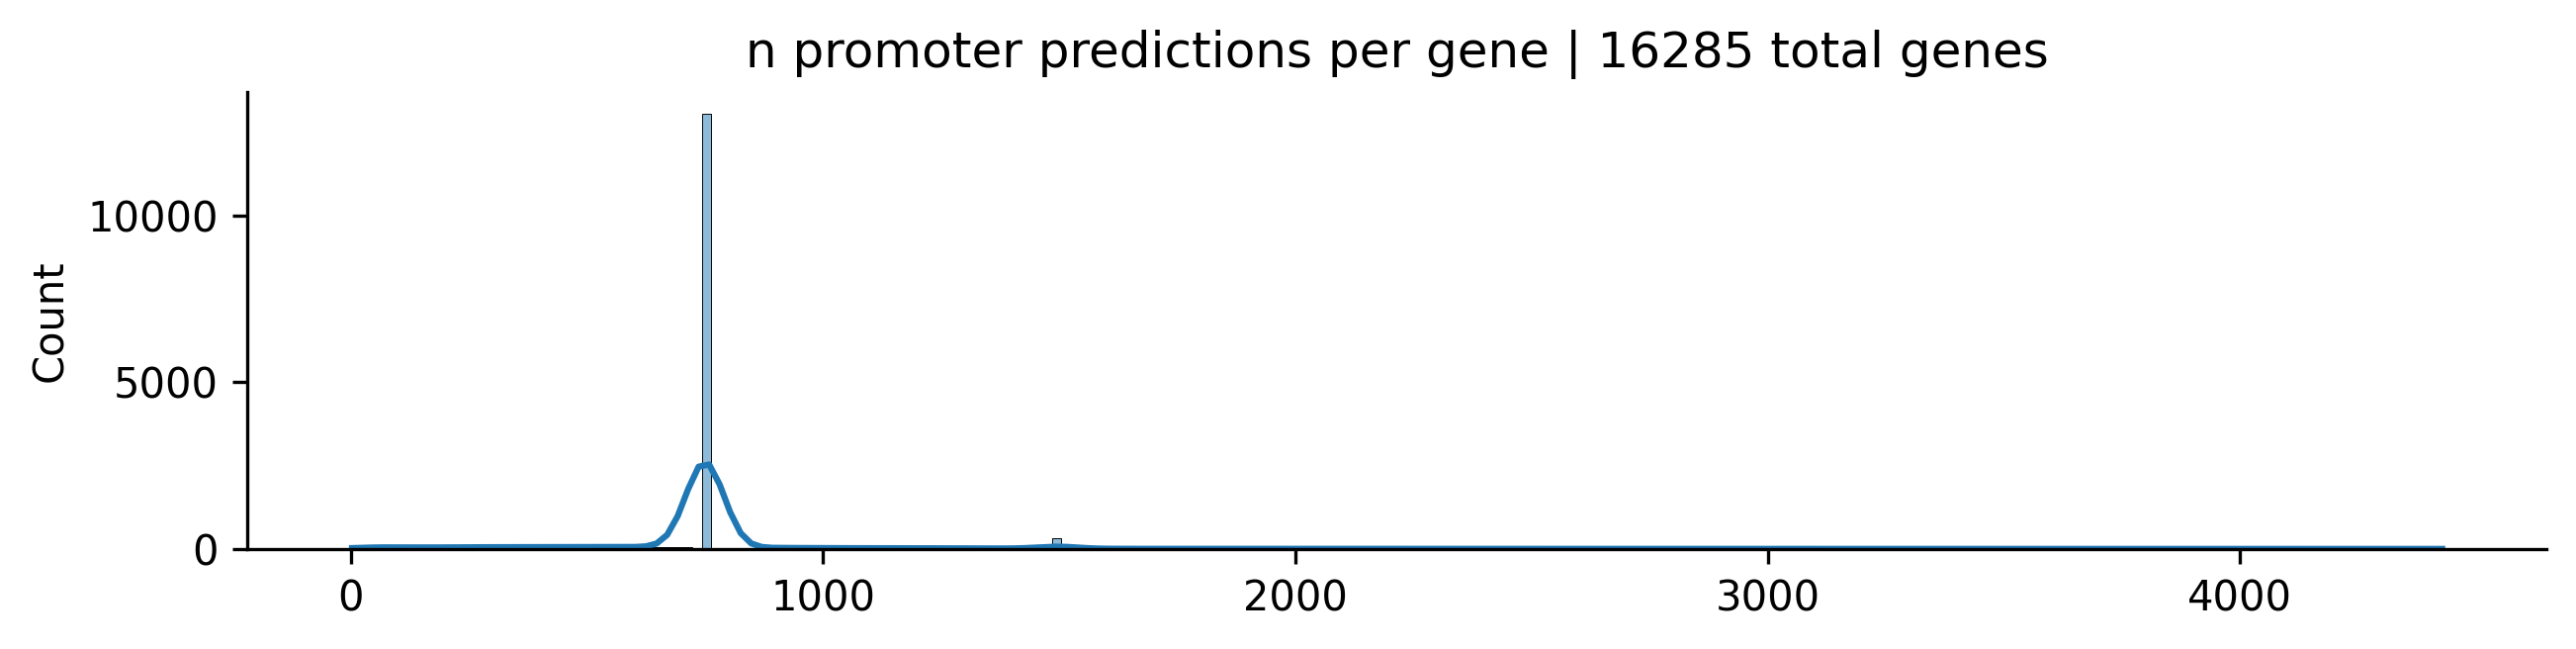

In [6]:
# get a summary of predictions
print(f'There are {len(all_tabix_mpac_preds['gene_name'].unique())} unique gene IDs in the full predictions')
# make a counter of gene_names
gene_name_count = Counter(all_tabix_mpac_preds['gene_name'])
# plot the distributions of predictions per ID
mpl.figure(dpi=300, figsize=(10,2))
sns.histplot(gene_name_count.values(), binwidth=20, kde=True, legend=False)
#mpl.xticks([250, 500, 750, 1000, 1250, 1500, 1750],
#           [250, 500, 750, 1000, 1250, 1500, 1750])
sns.despine()
mpl.title(f'n promoter predictions per gene | {len(all_tabix_mpac_preds['gene_name'].unique())} total genes')
# as expected, the majority are 750bp total, however, there are some that have overlapping promoters that are > 750 predictions, let's get the 250bp promoters only
# and do an annotation check that there aren't overlapping intervals that happen to be 750 bp
twoFifty_single_genes = [i for i in gene_name_count.keys() if gene_name_count.get(i) == 750 and len(i.split(':')) == 1]
print(f'There are {len(twoFifty_single_genes)} non-overlapping promoters with complete sat mut predictions')
# get a list of the promoters that are overlapping, less than 250bp, etc. for tracking
misfit_genes = set(list(all_tabix_mpac_preds['gene_name'].unique())) - set(twoFifty_single_genes)
print(f'There are {len(misfit_genes)} genes that are not passing filtering')
# do a quick check that the total number of passing genes and non-passing genes equals the total number of genes
print((len(twoFifty_single_genes) + len(misfit_genes) == len(all_tabix_mpac_preds['gene_name'].unique())))
# filter all predictions for only the promoters passing filters
filtered_mpac_preds = all_tabix_mpac_preds[all_tabix_mpac_preds['gene_name'].isin(twoFifty_single_genes)]
# confirm the counts of each gene
print(pd.Series(Counter(filtered_mpac_preds['gene_name']).values()).unique()[0] == 750)

In [7]:
# okay so we have 130003 promoters passing filtering, let's use all those for calling seqlets
# define our function for generating tensors
def predictions_to_tensors_multi_cell(df):
    """
    Converts a DataFrame with multi-cell type saturation mutagenesis
    predictions into a nested dictionary of tensors.

    Args:
        df (pd.DataFrame):
            DataFrame with columns like 'id', 'pos', 'ref', 'alt',
            and cell-specific columns such as 'k562_skew_pred'.

    Returns:
        dict: A nested dictionary in the format {cell_type: {id: tensor}},
              where each tensor is a (4, sequence_length) PyTorch tensor.
    """
    # make a list for storing misfitting genes #
    misfit_genes = []
    # Dynamically find cell types from column names (e.g., 'k562_skew_pred')
    cell_types = sorted(list(set([col.split('_')[0] for col in df.columns if '_skew_pred' in col])))
    print(f"Detected cell types: {', '.join(cell_types)}")
    
    # A mapping from DNA base to the tensor row index
    base_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    
    # Initialize the nested dictionary structure
    tensor_dict = {cell: {} for cell in cell_types}
    
    # Group by the gene/enhancer ID
    for gene_id, gene_df in tqdm(df.groupby('gene_name'), desc="Converting IDs to Tensors"):
        
        # Temp dict to hold lists of position vectors for each cell type
        position_vectors_by_cell = {cell: [] for cell in cell_types}

        # Within each gene's data, group by position
        for pos, pos_df in gene_df.groupby('pos'):
            
            # Create a 4-element vector for each cell type for this position
            score_vectors = {cell: [0.0] * 4 for cell in cell_types}
            
            # Fill in the scores for the alternate bases for each cell type
            for _, row in pos_df.iterrows():
                alt_base_index = base_map[row['alt'].upper()]
                for cell in cell_types:
                    score_col = f"{cell}_skew_pred"
                    score_vectors[cell][alt_base_index] = row[score_col]
            
            # Append the completed vector for each cell type
            for cell in cell_types:
                position_vectors_by_cell[cell].append(score_vectors[cell])
                
        # After processing all positions, create the final tensor for each cell type
        for cell in cell_types:
            final_tensor = torch.tensor(position_vectors_by_cell[cell], dtype=torch.float32).T
            # check the length of the tensor
            if final_tensor.shape[-1] == 250:
                tensor_dict[cell][gene_id] = final_tensor
            else:
                misfit_genes.append(gene_id)
    return tensor_dict, misfit_genes

In [8]:
# generate raw tensors for each cell type eg for A : [o, skew, skew, skew], etc.
mpac_promoter_rawTensors, misfit_tensor_ids = predictions_to_tensors_multi_cell(filtered_mpac_preds)

Detected cell types: hepg2, k562, sknsh


Converting IDs to Tensors: 100%|██████████| 13003/13003 [10:15<00:00, 21.12it/s]


In [9]:
# mismatches are the same in all cell types, hence the triplicate
pd.Series(misfit_tensor_ids).unique()
# checking all the intervals for those genes shows they are all overlapping other promoters, good to drop

array(['C6orf120', 'PPAT', 'PSPH'], dtype=object)

In [10]:
# store the dictionary keys (promoter names) as a list for annotating seqlets, oneHots, etc.
promoter_list = list(mpac_promoter_rawTensors['k562'].keys())
# stack the tensors for each cell type
# k562
k_rawStacked = torch.stack([mpac_promoter_rawTensors['k562'][i] for i in promoter_list])
# hepg2
h_rawStacked = torch.stack([mpac_promoter_rawTensors['hepg2'][i] for i in promoter_list])
# sknsh
s_rawStacked = torch.stack([mpac_promoter_rawTensors['sknsh'][i] for i in promoter_list])

In [11]:
# define funtion for returning seqlets, oneHot encoded tensors, and plotLogo tensors for each cell type
def tensors4tangermeme (stacked_raw_tensors, gene_list):
    # make empty dictionaries for each type of seqlet to return
    seqlet_dict = {}
    plotLogo_dict = {}
    oneHot_dict = {}

    # iterate through stacked tensors and modify for each type
    for index, promoter in enumerate(gene_list):
        # pull the tensor to modify
        raw_tensor = stacked_raw_tensors[index]
        # make oneHot tensor
        oneHot_tensor = 1 * (raw_tensor == 0)
        # make seqlet tensor
        seqlet_tensor = (-1 * (raw_tensor.sum(dim=0))) / 3
        # make plot logo tensor
        plotLogo_tensor = oneHot_tensor * seqlet_tensor
        # update dictionaries
        seqlet_dict[promoter] = seqlet_tensor
        plotLogo_dict[promoter] = plotLogo_tensor
        oneHot_dict[promoter] = oneHot_tensor
    return seqlet_dict, plotLogo_dict, oneHot_dict;

In [12]:
# return tensors for each cell type
# k562
k_seqlet_dict, k_plotLogo_dict, k_oneHot_dict = tensors4tangermeme(k_rawStacked, promoter_list)
# hepg2
h_seqlet_dict, h_plotLogo_dict, h_oneHot_dict = tensors4tangermeme(h_rawStacked, promoter_list)
# sknsh
s_seqlet_dict, s_plotLogo_dict, s_oneHot_dict = tensors4tangermeme(s_rawStacked, promoter_list)

In [13]:
# define a function for stacking each seqlet dictionary for each cell type
def stack_tensors (seqlet_dict, plotLogo_dict, oneHot_dict, promoters):
    # stack seqlets
    seqlet_stack = torch.stack([seqlet_dict[promoter] for promoter in promoters])
    # stack plotLogos
    plotLogo_stack = torch.stack([plotLogo_dict[promoter] for promoter in promoters])
    # stack oneHots
    oneHot_stack = torch.stack([oneHot_dict[promoter] for promoter in promoters])
    return seqlet_stack, plotLogo_stack, oneHot_stack;

In [14]:
# stack all tensors for calling seqlets, annotating them, etc.
# k562
k_stackedSeqlets, k_stackedPlotLogos, k_stackedOneHots = stack_tensors(k_seqlet_dict, k_plotLogo_dict, k_oneHot_dict, promoter_list)
# hepg2
h_stackedSeqlets, h_stackedPlotLogos, h_stackedOneHots = stack_tensors(h_seqlet_dict, h_plotLogo_dict, h_oneHot_dict, promoter_list)
# sknsh
s_stacked_Seqlets, s_stackedPlotLogos, s_stackedOneHots = stack_tensors(s_seqlet_dict, s_plotLogo_dict, s_oneHot_dict, promoter_list)

In [15]:
# call seqlets for each cell type
# k562
k_seqlet_calls = recursive_seqlets(k_stackedSeqlets, threshold=0.01)
# hepg2
h_seqlet_calls = recursive_seqlets(h_stackedSeqlets, threshold=0.01)
# sknsh
s_seqlet_calls = recursive_seqlets(s_stacked_Seqlets, threshold=0.01)

In [16]:
# define a function for annotating seqlets
def ann_seqlets (path2pwms, motif_database, stacked_oneHots, seqlet_calls, promoters):
    # store motif info as a variable
    motif_path = f'{path2pwms}/{motif_database}'
    # open pwms
    motifs = read_meme(motif_path)
    motif_names = list(motifs.keys())
    # run annotate seqlets
    motif_idxs, motif_pvals = annotate_seqlets(stacked_oneHots, seqlet_calls, motif_path)
    # make a dictionary of indices and gene names for annotating promoters
    promoter_idx_dict = dict(zip([promoters.index(i) for i in promoters], promoters))
    # make copies of the seqlet DFs for annotating with promoter names and tf names
    # tf for plotLogos
    tf_ann_seqlets = seqlet_calls.copy()
    tf_ann_seqlets.loc[:,'example_idx'] = [motif_names[idx] for idx in motif_idxs] # use this one with plotLogos
    # tf + promoter id
    full_ann_seqlets = seqlet_calls.copy()
    # add enhancer ids
    full_ann_seqlets.loc[:, 'promoter_id'] = [promoter_idx_dict.get(i) for i in full_ann_seqlets['example_idx']]
    # add matching motif
    full_ann_seqlets.loc[:,'example_idx'] = [motif_names[idx] for idx in motif_idxs]
    # add pval of match
    full_ann_seqlets.loc[:,'pval'] = [float(i[0]) for i in motif_pvals]
    return tf_ann_seqlets, full_ann_seqlets;

In [17]:
# annotate seqlets for each cell type
# k562
k_tf_ann_seqlets, k_full_ann_seqlets = ann_seqlets('/projects/tewhey-lab/buttsj/meme_suite_data/motif_databases/HOCOMOCO/',
                                                        'HOCOMOCOv11_core_HUMAN_mono_meme_format.meme',
                                                        k_stackedOneHots,
                                                        k_seqlet_calls,
                                                        promoter_list)
# hepg2
h_tf_ann_seqlets, h_full_ann_seqlets = ann_seqlets('/projects/tewhey-lab/buttsj/meme_suite_data/motif_databases/HOCOMOCO/',
                                                        'HOCOMOCOv11_core_HUMAN_mono_meme_format.meme',
                                                        h_stackedOneHots,
                                                        h_seqlet_calls,
                                                        promoter_list)
# sknsh
s_tf_ann_seqlets, s_full_ann_seqlets = ann_seqlets('/projects/tewhey-lab/buttsj/meme_suite_data/motif_databases/HOCOMOCO/',
                                                        'HOCOMOCOv11_core_HUMAN_mono_meme_format.meme',
                                                        s_stackedOneHots,
                                                        s_seqlet_calls,
                                                        promoter_list)

/tmp/ipykernel_2086243/3739010979.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['ELK1_HUMAN.H11MO.0.B', 'ELK1_HUMAN.H11MO.0.B', 'GFI1_HUMAN.H11MO.0.C', 'ELK1_HUMAN.H11MO.0.B', 'NRF1_HUMAN.H11MO.0.A', 'KAISO_HUMAN.H11MO.0.A', 'SP1_HUMAN.H11MO.0.A', 'TGIF1_HUMAN.H11MO.0.A', 'BACH2_HUMAN.H11MO.0.A', 'NRF1_HUMAN.H11MO.0.A', 'KAISO_HUMAN.H11MO.0.A', 'GFI1_HUMAN.H11MO.0.C', 'ZN770_HUMAN.H11MO.0.C', 'GFI1_HUMAN.H11MO.0.C', 'ELK1_HUMAN.H11MO.0.B', 'GFI1_HUMAN.H11MO.0.C', 'SP1_HUMAN.H11MO.0.A', 'KLF12_HUMAN.H11MO.0.C', 'HIC1_HUMAN.H11MO.0.C', 'ZBTB6_HUMAN.H11MO.0.C', 'CREM_HUMAN.H11MO.0.C', 'NF2L2_HUMAN.H11MO.0.A', 'REST_HUMAN.H11MO.0.A', 'ELK1_HUMAN.H11MO.0.B', 'NRF1_HUMAN.H11MO.0.A', 'KLF12_HUMAN.H11MO.0.C', 'NF2L2_HUMAN.H11MO.0.A', 'NF2L2_HUMAN.H11MO.0.A', 'GFI1_HUMAN.H11MO.0.C', 'ELK1_HUMAN.H11MO.0.B', 'ELK1_HUMAN.H11MO.0.B', 'TF65_HUMAN.H11MO.0.A', 'ZBTB6_HUMAN.H11MO.0.C', 'ELK1_HUMAN.H11MO.0.B', 'TEAD1_HUMAN.H

In [18]:
def plot_specific_logos (seqlets,
                         annotated_seqlets,
                         promoter_id,
                         plotLogo_tensors,
                         cell):
    # define highlight color
    if cell == 'K562':
        highlight = '#00A79D'
    elif cell == 'HepG2':
        highlight = '#FBB040'
    elif cell == 'SKNSH':
        highlight = '#ED1C24'
    # make a dictionary for annotating seqlets calls with promoters
    promoter_idx = list(plotLogo_tensors.keys()).index(promoter_id)
    # filter for the random enhancer by enhancer index
    pro_seqlets = seqlets[seqlets['example_idx'] == promoter_idx]
    pro_ann = annotated_seqlets.iloc[pro_seqlets.index]
    if len(pro_seqlets) > 0:
        mpl.figure(figsize=(20,1), dpi=300)
        ax = mpl.subplot(111)
        plot_logo(plotLogo_tensors[promoter_id], annotations=pro_ann, score_key='attribution')
        for idx, row in pro_seqlets.iterrows():
            start, stop = row[['start', 'end']].tolist()
            ax.axvspan(start - 0.5, stop + 0.5, alpha=0.15, color=highlight)
        #mpl.ylim(-.5, .5)
        mpl.title(f'{cell} | tangermeme seqlets for {promoter_id}')
        mpl.show()
    else:
        print('no seqlets for this enhancer at this threshold')
        mpl.figure(figsize=(20,1), dpi=300)
        plot_logo(plotLogo_tensors[promoter_id])
        mpl.title(f'{cell} | tangermeme seqlets for {promoter_id}')
        mpl.show()

In [19]:
# define the optimized function for converting seqlets to a bed file
def seqlets2bed_optimized(full_preds,
                          full_ann_seqlets):
    """
    Converts seqlet predictions to a BED DataFrame using vectorized operations.
    """
    # 1. Get min position for each enhancer. This is already efficient.
    # The result is a Series where the index is 'id' and values are the min 'pos'.
    promoter_min_pos = full_preds.groupby('gene_name')['pos'].min()
    promoter_chrom = full_preds.groupby('gene_name')['chrom'].min()
    #promoter_attrib = 
    # Get the seqlets DataFrame from your dictionary
    seqlets = full_ann_seqlets.copy() # Use .copy() to avoid SettingWithCopyWarning

    # 2. Map the enhancer start positions to each seqlet.
    # This single vectorized operation replaces your entire outer 'for enh...' loop.
    seqlets['promoter_start'] = seqlets['promoter_id'].map(promoter_min_pos)
    seqlets['chrom'] = seqlets['promoter_id'].map(promoter_chrom)
    # Drop any seqlets whose enhancer_id was not found in 'full_preds'
    seqlets.dropna(subset=['promoter_start'], inplace=True)
    
    # Ensure the new column is an integer type for calculations
    seqlets['promoter_start'] = seqlets['promoter_start'].astype(int)

    # 3. Calculate BED coordinates and IDs vectorially.
    # These three lines replace your inner loop and all list appends.
    bed_start = seqlets['promoter_start'] + seqlets['start'] - 1 # Convert to 0-based
    bed_end = seqlets['promoter_start'] + seqlets['end']
    bed_id = seqlets['example_idx'].astype(str) + '_' + seqlets['promoter_id']
    # append attribution to id
    bed_id = [f'{i}_{str(j)}' for i, j in zip(bed_id, seqlets['attribution'].tolist())]
    chromosome = seqlets['chrom']
    # 4. Assemble the final DataFrame in one step.
    bed2return = pd.DataFrame({
        'chrom': chromosome,
        'start': bed_start,
        'end': bed_end,
        'id': bed_id
    }).sort_values(by=['chrom', 'start'])
    
    return bed2return

In [20]:
# generate BED files for each cell type
# k562
k_seqlet_bed = seqlets2bed_optimized(filtered_mpac_preds, k_full_ann_seqlets)
# hepg2
h_seqlet_bed = seqlets2bed_optimized(filtered_mpac_preds, h_full_ann_seqlets)
# sknsh
s_seqlet_bed = seqlets2bed_optimized(filtered_mpac_preds, s_full_ann_seqlets)

In [21]:
# save BED files to disk
# k562
#k_seqlet_bed.to_csv('../processed_data/bed_files/k562_mpac_annotated_seqlets_01.bed', sep = '\t', index = False, header = None)
# hepg2
#h_seqlet_bed.to_csv('../processed_data/bed_files/hepg2_mpac_annotated_seqlets_01.bed', sep = '\t', index = False, header = None)
# sknsh
#s_seqlet_bed.to_csv('../processed_data/bed_files/sknsh_mpac_annotated_seqlets_01.bed', sep = '\t', index = False, header = None)

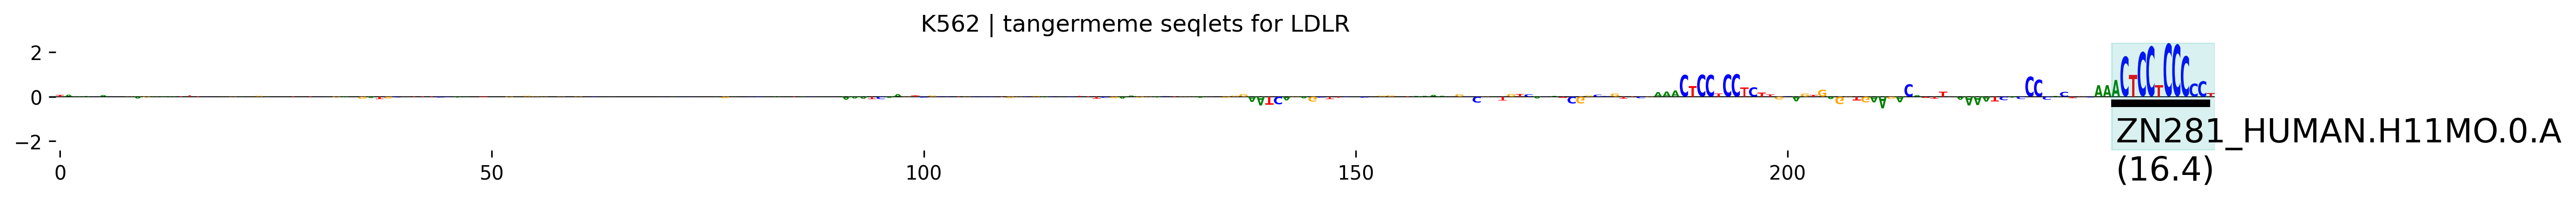

In [22]:
plot_specific_logos(k_seqlet_calls,
                    k_full_ann_seqlets,
                    'LDLR',
                    k_plotLogo_dict,
                    'K562')

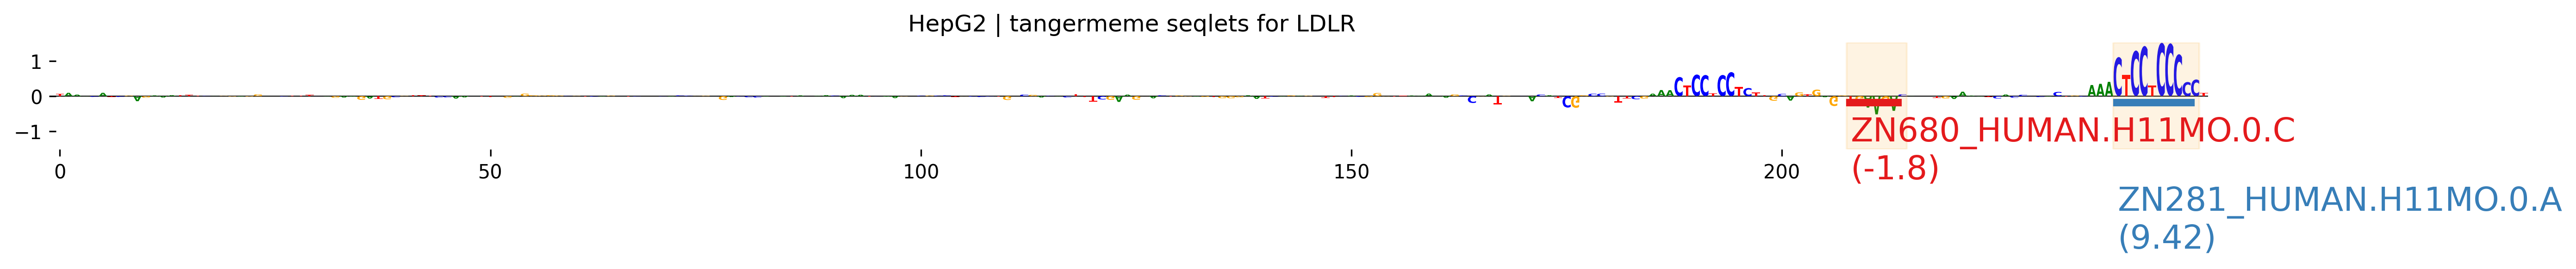

In [23]:
plot_specific_logos(h_seqlet_calls,
                    h_full_ann_seqlets,
                    'LDLR',
                    h_plotLogo_dict,
                    'HepG2')

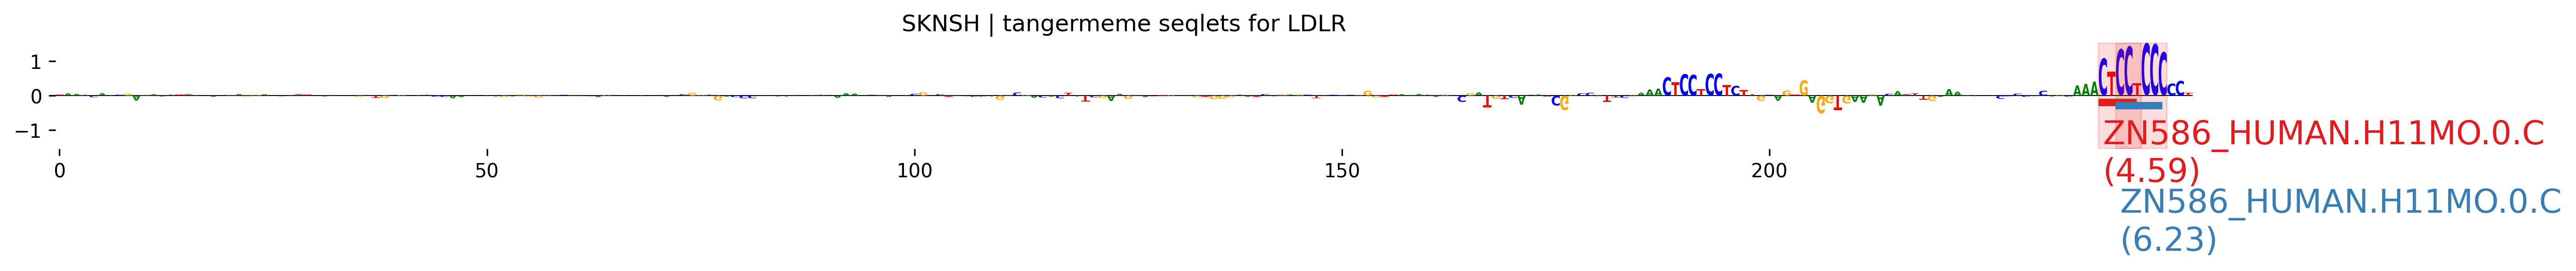

In [24]:
plot_specific_logos(s_seqlet_calls,
                    s_full_ann_seqlets,
                    'LDLR',
                    s_plotLogo_dict,
                    'SKNSH')

no seqlets for this enhancer at this threshold


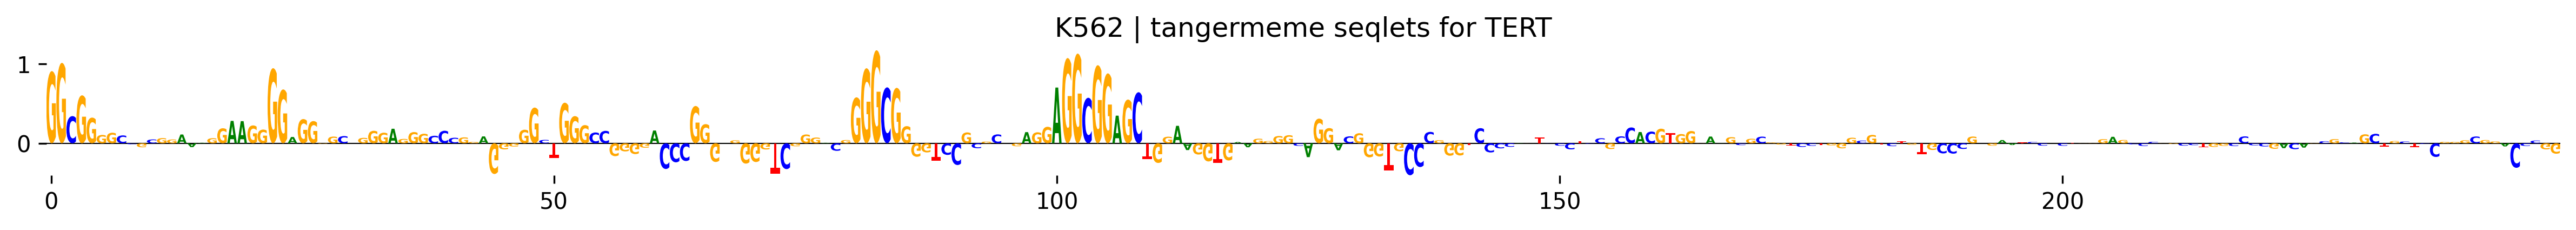

In [118]:
plot_specific_logos(k_seqlet_calls,
                    k_full_ann_seqlets,
                    'TERT',
                    k_plotLogo_dict,
                    'K562')

no seqlets for this enhancer at this threshold


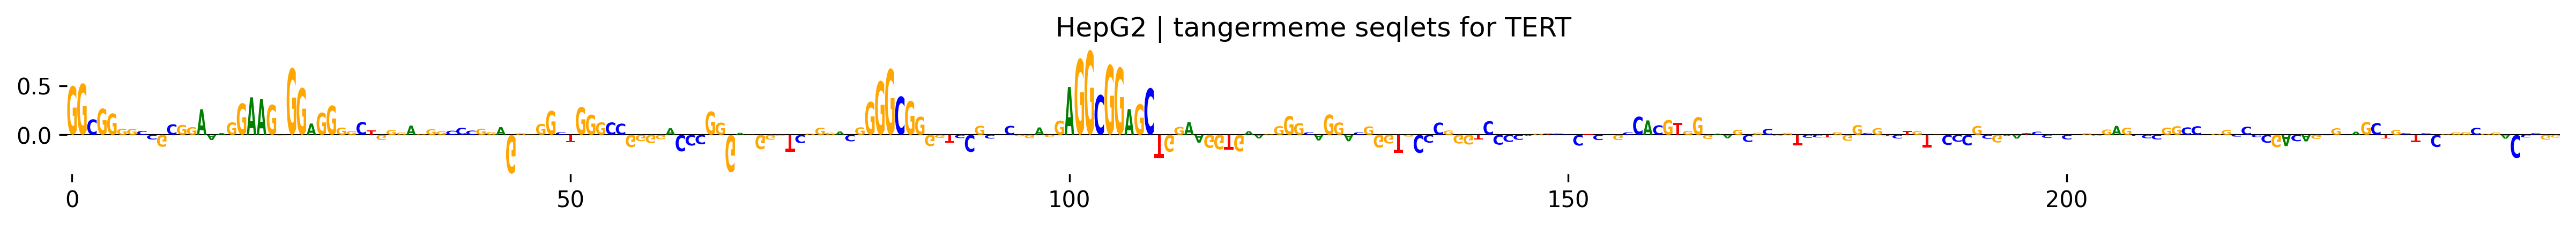

In [119]:
plot_specific_logos(h_seqlet_calls,
                    h_full_ann_seqlets,
                    'TERT',
                    h_plotLogo_dict,
                    'HepG2')

no seqlets for this enhancer at this threshold


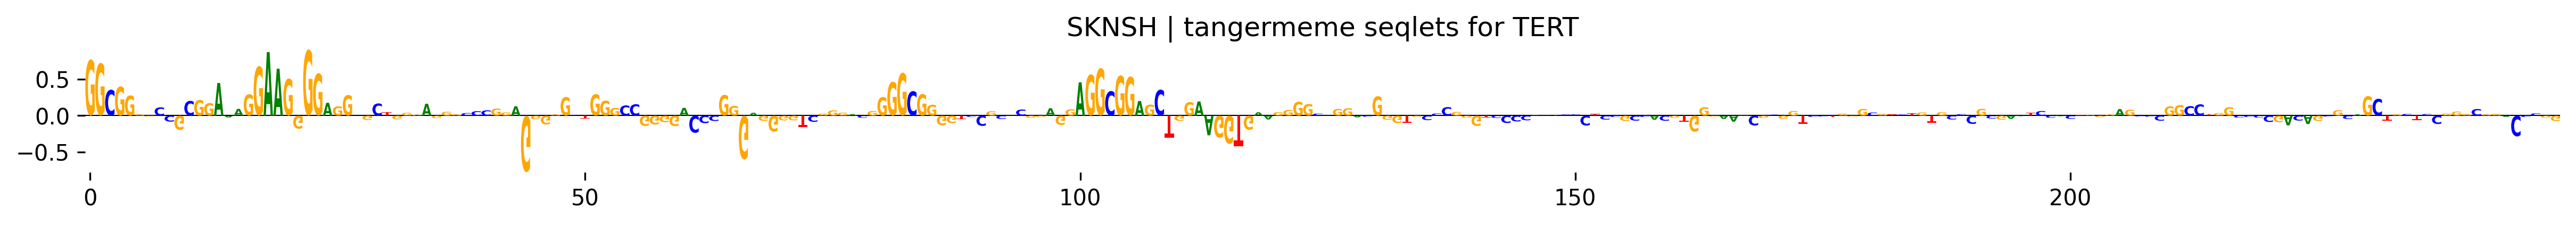

In [120]:
plot_specific_logos(s_seqlet_calls,
                    s_full_ann_seqlets,
                    'TERT',
                    s_plotLogo_dict,
                    'SKNSH')